In [10]:
import utils
import methods
from methods import Reservoir, DataGenerator

import torch

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import scipy.io as sio
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## Theory and Motivation

In general a time series represents a record of observations of a dynamical system at specific time intervals. Time series prediction involves predicting the next state of the system given the current state. The challenge lies in the prediction of the chaotic behavior of systems which are characterized by orbital instability, where slight differences in the initial values bring about large differences in the time series behavior.

Recurrent Neural Networks (RNN) serve are the mainstream architecture for analysing sequential data. This is due to the architecture having recurrent connections, which serve as a notion of memory, allowing them to embed temporal information.

We construct an Echo State Network (ESN) and implement several training approaches: 
+ Bayesian Inference over the regression parameter: via MCMC and stochastic Variatonal Inference (VI), and Stochastic Search Variable Selection (SVSS)
+ Quantile Regression (QR).

The goal of obtaining along-side the prediction an accurate confidence interval.

### Function of the Reservoir

**References**

[1] M. Guerra, S. Scardapane, and F. M. Bianchi,  
*Probabilistic Load Forecasting With Reservoir Computing*,  
IEEE Access, vol. 11, pp. 145989–146002, 2023.  
https://doi.org/10.1109/ACCESS.2023.3343467

[2] Mantas Lukoševičius.  
*A Practical Guide to Applying Echo State Networks*.  
In **Neural Networks: Tricks of the Trade – Reloaded**,  
Springer, 2012.

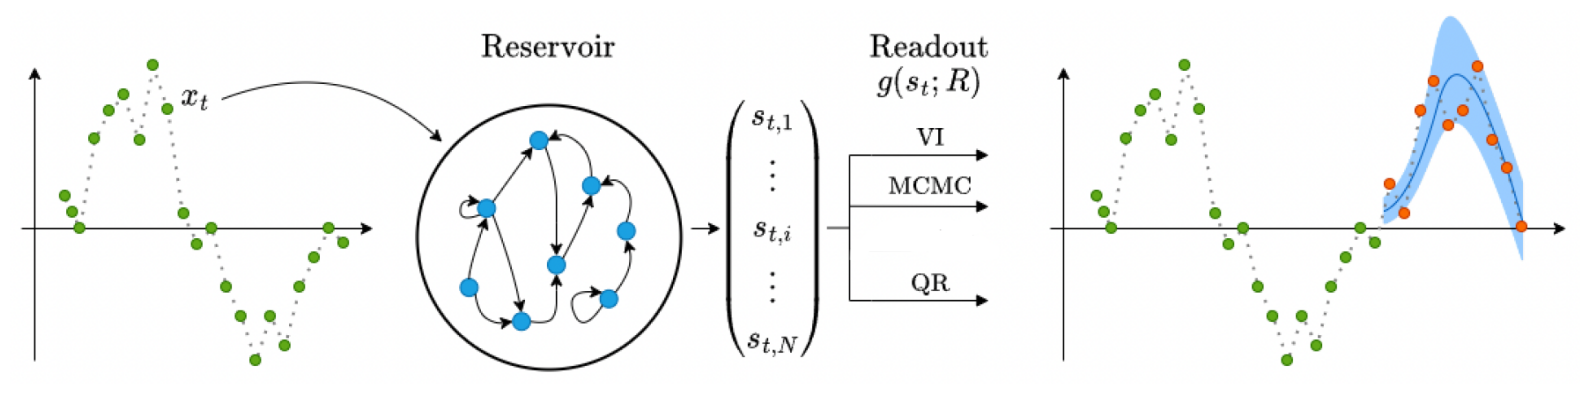

In [11]:
# Load the local image files
img_reservoir = mpimg.imread('images/reservoir_forecasting.png')

# Construct a 1x2 subplot grid
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(16, 6))

# Render Reservoir Architecture
axes.imshow(img_reservoir)
axes.axis('off')

plt.tight_layout()
plt.show()

Reservoir Computing (RC) is a learning paradigm that we implement using Echo State Networks (ESNs), with the training process limited to obtaining the output layer weights.

The typical equations of an ESN are the following:
$$
s(t)
=
\tanh\!\left(
\mathbf{W}^{\text{in}} [\,1;\,x(t)] + \mathbf{W}\,s(t-1)
\right),
$$
+ where $s(t)\in \mathbb{R}^{N_x}$ is a vector of reservoir neuron activations and is the update of $s(t-1)\in \mathbb{R}^{N_x}$
+ and $\mathbf{W}^{\text{in}} \in \mathbb{R}^{N_x \times (1+N_u)}$ and $\mathbf{W} \in \mathbb{R}^{N_x \times N_x}$ are the input and recurrent weight matrices respectively. 

The linear readout layer is defined as:
$$
y(t) = \mathbf{W}^{\text{out}} \,[\,1;\,x(t);\;s(t)\,],
$$
where $y(t)\in R^{N_y}$ is network output, $W_{\text{out}}\in R^{N_y \times (1+N_u+N_x)}$ the output weight matrix.

We point out that the reservoir has a twofold action:
+ a nonlinear expansion of the input ("kernel trick")
+ the reservoir serves as a memory providing temporal context.

### Global parameters of the Reservoir

The input and recurrent connection matrices $W_{\text{in}}$ and $W$ are generated randomly. Namely:
$$
\texttt{
W = np.random.uniform( -1, 1, (self.reservoir\_dim, self.reservoir\_dim) ) } \\
\texttt{
eigvals\_res = np.linalg.eigvals( W ) } \\
\texttt{ 
max\_radius = np.max( np.abs( eigvals\_res ) ) } \\
\texttt{
self.W = W * self.spectral\_radius / max\_radius } \\
\texttt{ 
self.W\_in = np.random.uniform( -1, 1, (self.reservoir\_dim, self.input\_dim) ) } 
$$
The defining global parameters of the reservoir are: 
+ the size $N_x$, the sparsity, the distribution of nonzero elements, and spectral radius of $W$;
+ the scaling(-s) of $W_{\text{in}}$.

In practice, we fix the scaling of $W_{\text{in}}$ by setting the bounds of the uniform random generator between $[-1,1]$. Furthermore we set:
+ $N_x = 500$ based on the paper *Probabilistic Load Forecasting With Reservoir Computing* by Guerra, Scardapane, and Bianchi.
+ Use the spectral radius as single parameter of sparsity.

For the ESN approach to work, the reservoir should satisfy the so-called echo state property: the state of the reservoir $s(t)$ should be uniquely defined by the fading history of the input $x(t)$. In other words, for a long enough input $x(t)$, the reservoir state $s(t)$ should not depend on the initial conditions that were before the input.

## Data 

To evaluate the performance of the different training approache in probabilistic forecasting of chaotic time-series we use a chaotic benchmark and two experimental datasets containing rs-fMRI brain signal from the same subject.

The Synthetic Dataset will serve as the controlled environment. It will be used to prove our Bayesian algorithms and ESN are implemented correctly. 

The real brain data is noisy, high-dimensional, and stochastic. We will use it to evaluate how your different inference methods (MCMC vs. VI vs. SSVS vs. QR) scale, perform, and degrade when the theoretical guarantees given by a deterministic model disappear.

### Synthetic Dataset

**Reference**

[3] S. Shahi, F. H. Fenton, and E. M. Cherry,  
*Prediction of chaotic time series using recurrent neural networks and reservoir computing techniques: A comparative study*,  
Chaos, Solitons & Fractals, 2022.

#### Mackey–Glass Equation

The Mackey–Glass delay differential equation (continuous form):

$$
\frac{dx(t)}{dt} = \beta \frac{x(t-\tau)}{1 + x(t-\tau)^n} - \gamma x(t)
$$

We use a discrete Euler approximation in the generator implemented in this notebook:

$$
x_{t+\Delta t} = x_t + \Delta t \left( \beta \frac{x_{t-\tau}}{1 + x_{t-\tau}^n} - \gamma x_t \right)
$$

Where: $\tau$ is the delay, $n$ the nonlinearity exponent, $\beta$ and $\gamma$ are parameters controlling feedback and decay, and $\Delta t$ is the integration step.

For the Mackey-Glass system generated with a physical delay $\tau$ and integration step $\Delta t$, the discrete delay index is calculated as $\tau/\Delta t$.


In [12]:
Time_steps = 25000
burnin_steps = 1000
stride = 10
tau = 17
n = 10
beta = 0.2
gamma = 0.10
delta_t = 0.1

X1, Y1 = DataGenerator(Time_steps, tau, n=10, beta=0.2, gamma=0.1, delta_t=0.1, init_steps=burnin_steps , under_samp=stride).generate_data()
X2, Y2 = DataGenerator(Time_steps, tau, n=10, beta=0.2, gamma=0.1, delta_t=0.1, init_steps=burnin_steps , under_samp=stride).generate_data()

X1 = X1[burnin_steps::stride]
X1 += torch.randn(X1.shape) * 0.3
X1 = X1.float()

X2 = X2[burnin_steps::stride]
X2 += torch.randn(X2.shape) * 0.3
X2 = X2.float()

synth_1D = np.asarray(X1).squeeze()


input_dim = X1.shape[1]
reservoir_dim = 500
spectral_radius = 0.9
seed = 42

res = Reservoir(input_dim, reservoir_dim, spectral_radius, seed)

S1 = res.get_states(X1.numpy())

print(f"Input shape: {X1.shape}")

print(f"Reservoir States shape: {S1.shape}")

Input shape: torch.Size([2400, 1])
Reservoir States shape: (2400, 500)


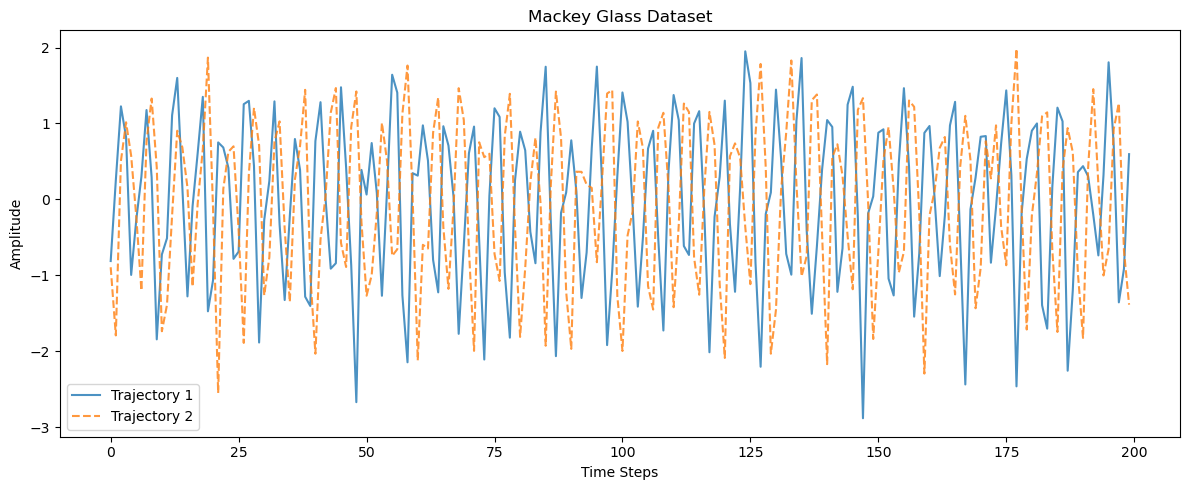

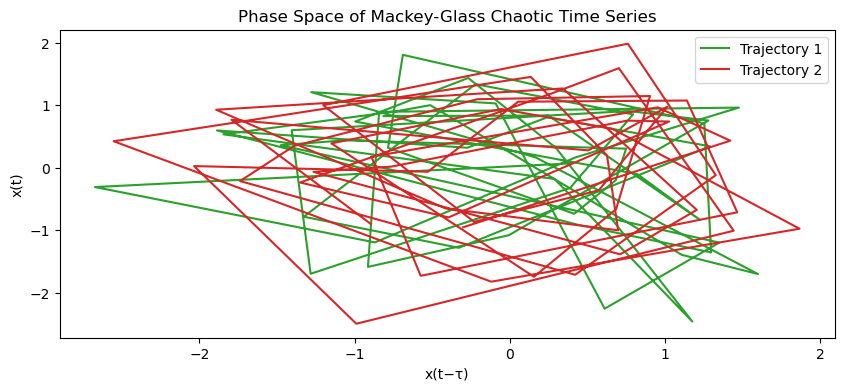

In [37]:
limit = 200

plt.figure(figsize=(12, 5))
plt.plot(X1[:limit], label="Trajectory 1", color="C0", alpha=0.8)
plt.plot(X2[:limit], label="Trajectory 2", color="C1", alpha=0.8, linestyle="--")
plt.title("Mackey Glass Dataset")
plt.xlabel("Time Steps")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

lim = 50
delay_steps = int(tau / delta_t)

plt.figure(figsize=(10, 4))
plt.plot(X1[:-delay_steps][:lim], X1[delay_steps:][:lim], color='C2', label="Trajectory 1")
plt.plot(X2[:-delay_steps][:lim], X2[delay_steps:][:lim], color='C3', label="Trajectory 2")
plt.title("Phase Space of Mackey-Glass Chaotic Time Series")
plt.legend()
plt.xlabel("x(t−τ)")
plt.ylabel("x(t)")
plt.show()

## Real dataset

We load the real fMRI time series and compare basic statistics, power spectra and autocorrelations with the synthetic Mackey–Glass series.

In [14]:
# Load the MAT file
mat_file1 = sio.loadmat('100307.REST1.LR.SchaeferS.ptseries.mat')
mat_file2 = sio.loadmat('100307.REST2.LR.SchaeferS.ptseries.mat')

In [15]:
real_data1 = torch.from_numpy(mat_file1['tseries']).float().T
real1_np = real_data1.cpu().numpy()
real1_np.shape

(1200, 119)

In [16]:
real_data2 = torch.from_numpy(mat_file2['tseries']).float().T
real2_np = real_data2.cpu().numpy()
real2_np.shape

(1200, 119)

### Understand `real_data`

We standardize the real dataset to a `(TimeSteps, Regions)` NumPy Array, verify shapes and basic statistics, as well as functional correlations.

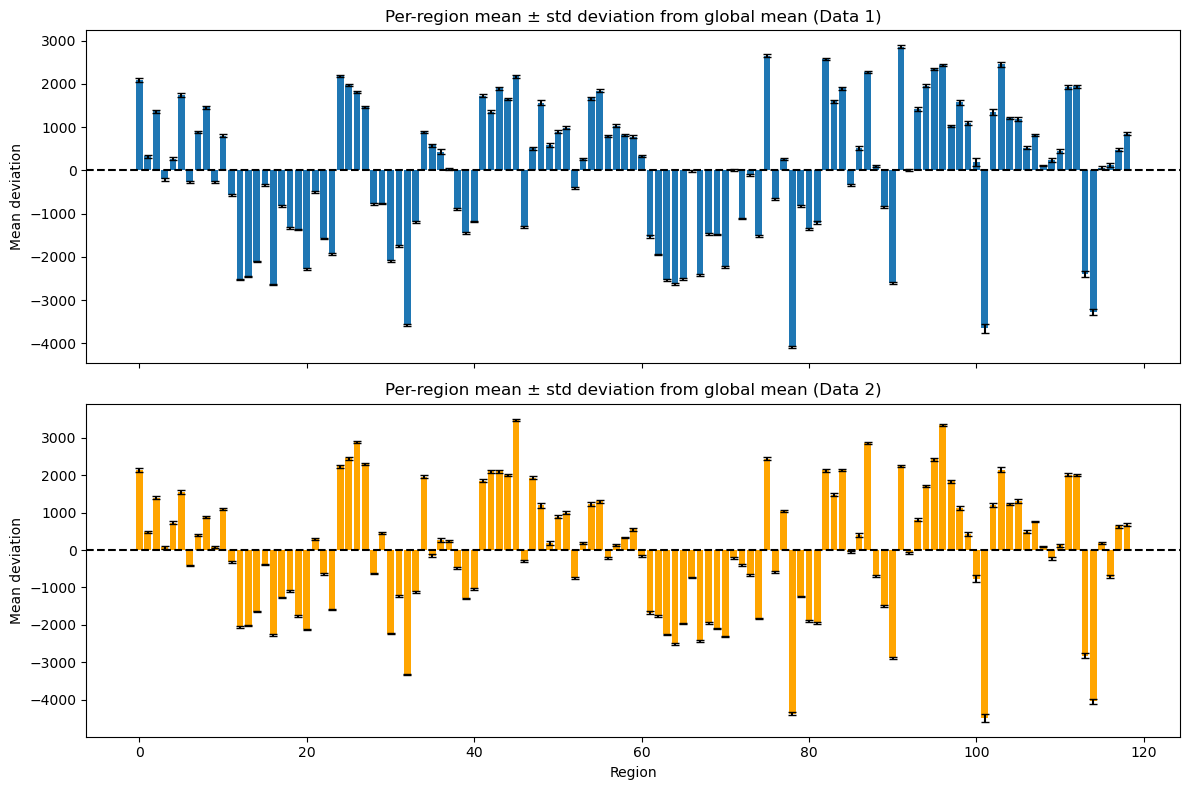

In [17]:
# Compute deviations from the global mean time-series (Data 1)
global1_mean = real1_np.mean(axis=1)
dev1 = real1_np - global1_mean[:, None]

region1_dev_mean = dev1.mean(axis=0)
region1_dev_std  = dev1.std(axis=0)

# Compute deviations from the global mean time-series (Data 2)
global2_mean = real2_np.mean(axis=1)
dev2 = real2_np - global2_mean[:, None]

region2_dev_mean = dev2.mean(axis=0)
region2_dev_std  = dev2.std(axis=0)

# Create vertically stacked subplots sharing the x-axis
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

# Plot Data 1 on the top subplot
axes[0].bar(np.arange(len(region1_dev_mean)), region1_dev_mean, yerr=region1_dev_std, capsize=3)
axes[0].axhline(0, color='k', linestyle='--')
axes[0].set_ylabel('Mean deviation')
axes[0].set_title('Per-region mean ± std deviation from global mean (Data 1)')

# Plot Data 2 on the bottom subplot
axes[1].bar(np.arange(len(region2_dev_mean)), region2_dev_mean, yerr=region2_dev_std, capsize=3, color="orange")
axes[1].axhline(0, color='k', linestyle='--')
axes[1].set_ylabel('Mean deviation')
axes[1].set_xlabel('Region')
axes[1].set_title('Per-region mean ± std deviation from global mean (Data 2)')

plt.tight_layout()
plt.show()

In [18]:
real1_z = (real1_np - real1_np.mean(axis=0)) / (real1_np.std(axis=0)  + 1e-8)
real2_z = (real2_np - real2_np.mean(axis=0)) / (real2_np.std(axis=0)  + 1e-8)

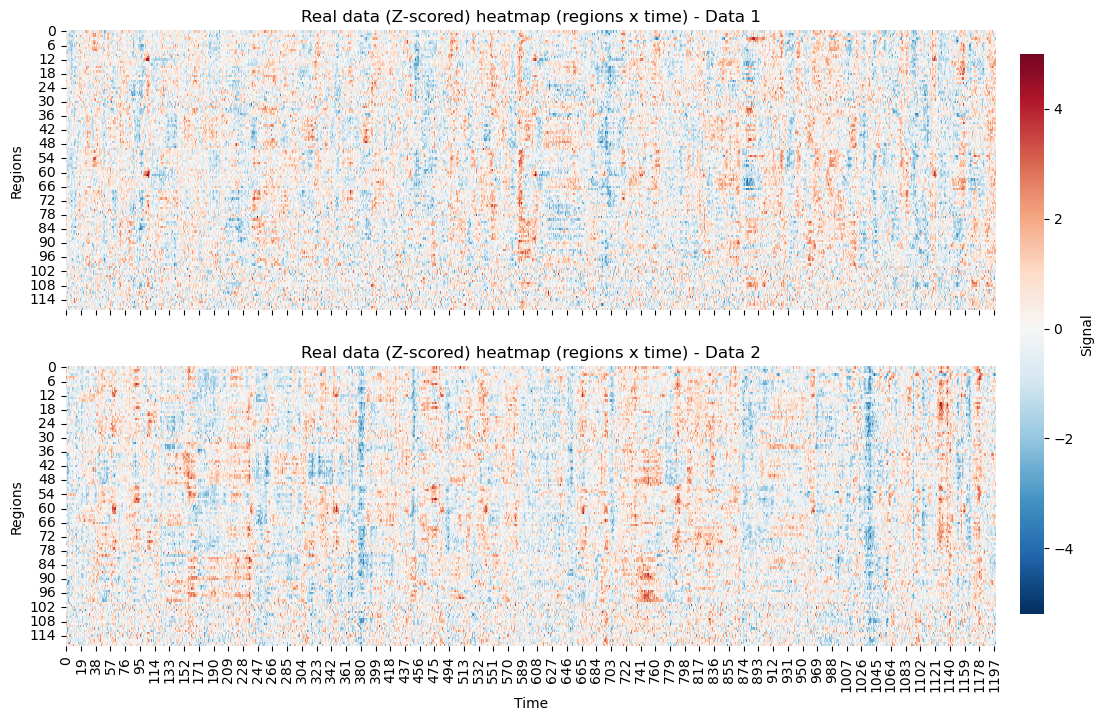

In [19]:
# Determine global min and max to ensure the shared colorbar is accurate for both datasets
vmin_sig = min(real1_z.min(), real2_z.min())
vmax_sig = max(real1_z.max(), real2_z.max())

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

# Create a dedicated axis for the colorbar: [left, bottom, width, height]
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) 

# Data 1 (Top)
sns.heatmap(real1_z.T, cmap='RdBu_r', center=0, vmin=vmin_sig, vmax=vmax_sig, 
            ax=axes[0], cbar=False)
axes[0].set_title('Real data (Z-scored) heatmap (regions x time) - Data 1')
axes[0].set_ylabel('Regions')

# Data 2 (Bottom)
sns.heatmap(real2_z.T, cmap='RdBu_r', center=0, vmin=vmin_sig, vmax=vmax_sig, 
            ax=axes[1], cbar=True, cbar_ax=cbar_ax, cbar_kws={'label':'Signal'})
axes[1].set_title('Real data (Z-scored) heatmap (regions x time) - Data 2')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Regions')

# Adjust layout to prevent overlap with the colorbar
plt.subplots_adjust(right=0.9)
plt.show()

Hint of spatial coupling across regions.

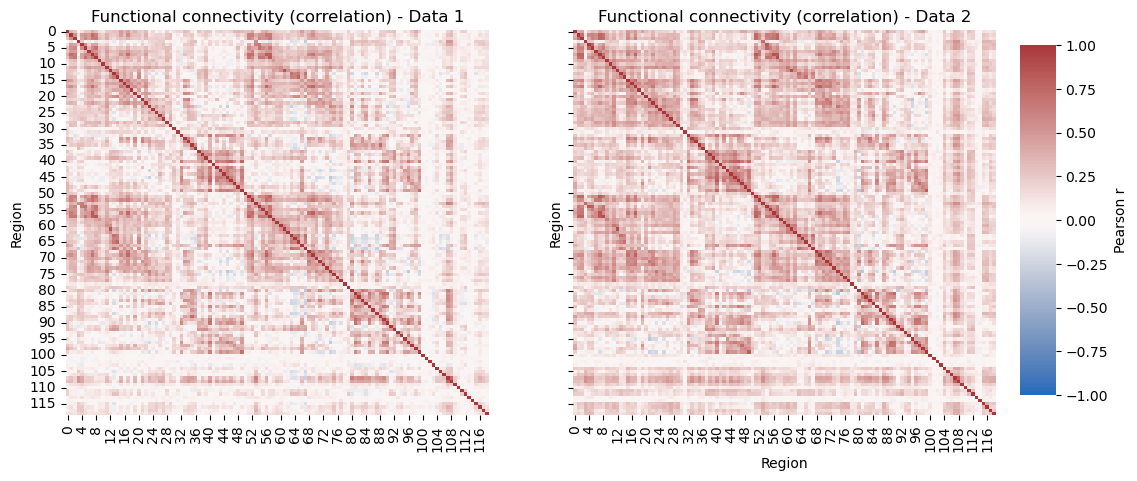

In [20]:
corr1 = np.corrcoef(real1_z.T)
corr2 = np.corrcoef(real2_z.T)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharex=True, sharey=True)

# Create a dedicated axis for the colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.03, 0.7]) 

# Data 1 (Top)
sns.heatmap(corr1, vmin=-1, vmax=1, cmap='vlag', 
            ax=axes[0], cbar=False)
axes[0].set_title('Functional connectivity (correlation) - Data 1')
axes[0].set_ylabel('Region')

# Data 2 (Bottom)
sns.heatmap(corr2, vmin=-1, vmax=1, cmap='vlag', 
            ax=axes[1], cbar=True, cbar_ax=cbar_ax, cbar_kws={'label':'Pearson r'})
axes[1].set_title('Functional connectivity (correlation) - Data 2')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Region')

# Adjust layout to prevent overlap with the colorbar
plt.subplots_adjust(right=0.9)
plt.show()

Hint of spatial coupling and high-dimensional cross-talk across several regions.

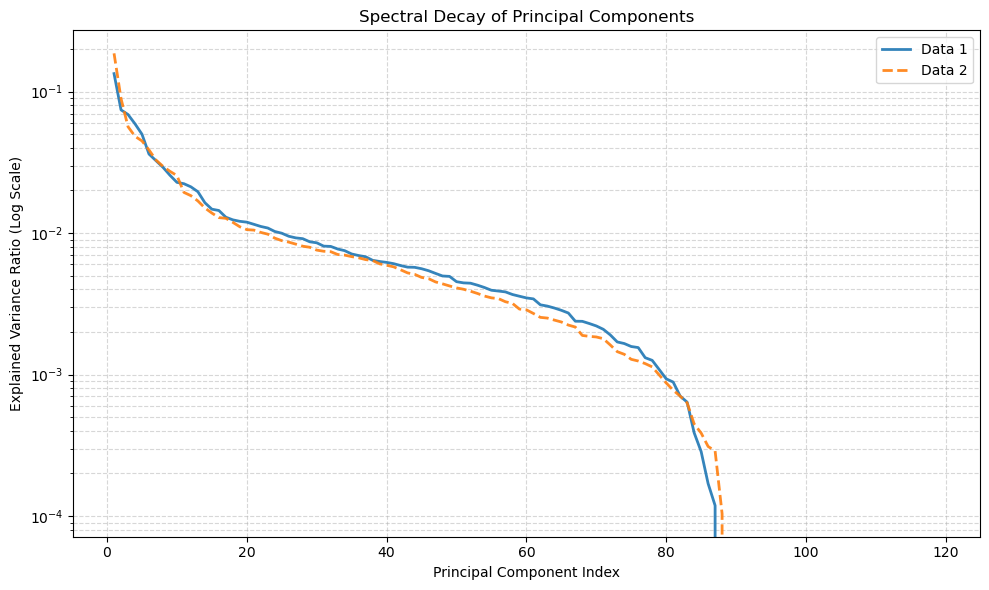

In [21]:
n_components = real1_np.shape[1]

pca1 = PCA(n_components=n_components)
pca1.fit(real1_np)
evr1 = pca1.explained_variance_ratio_

pca2 = PCA(n_components=n_components)
pca2.fit(real2_np)
evr2 = pca2.explained_variance_ratio_

components_axis = np.arange(1, n_components + 1)

plt.figure(figsize=(10, 6))
plt.plot(components_axis, evr1, label='Data 1', alpha=0.9, linewidth=2)
plt.plot(components_axis, evr2, label='Data 2', alpha=0.9, linewidth=2, linestyle='--')

plt.yscale('log')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio (Log Scale)')
plt.title('Spectral Decay of Principal Components')
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Comparison

In [22]:
region_idx = np.random.choice(real_data1.shape[1])
real_region_z = real1_z[:, region_idx]

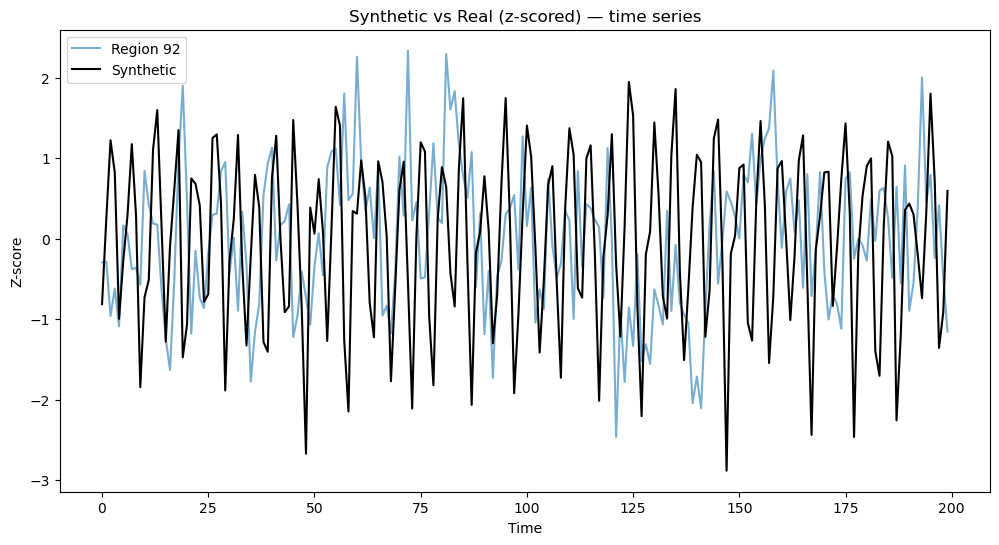

In [28]:
# Visualize stacked plots

plt.figure(figsize=(12,6))
plt.plot(real_region_z[:limit], alpha=0.6, label=f'Region {region_idx}')
plt.plot(X1[:limit], alpha=1, label='Synthetic', color='black')
plt.legend()
plt.title('Synthetic vs Real (z-scored) — time series')
plt.xlabel('Time')
plt.ylabel('Z-score')
plt.show()

From the overlay of the two datasets we visualize whether with the selected paramters the MG dataset, despite being very different, somewhat resembles the variability of the real datatset, in the hope that a good performance on the synthetic dataset can lead to a decent performance on the brain data. 

## Metrics

We evaluate the model using metrics that **penalize** both for "being wrong" (**inexact signal amplitude / too narrow condifence interval**) and "unecessarily unsure" (**too wide confidence interval**). 

In the following we assume we are interested in predictions with a 95% confidence interval.

We use a twofold approach:

+ **With** (width) and **Empirical Coverage** (cov):
    $$
    \text{width} = \frac{1}T\sum_{t=1}^T(q_{0.025,t}\,-\,q_{0.975,t}) \\
    \text{cov} = \frac{1}T\sum_{t=1}^T\mathbb{1}\{q_{0.025,t}\,\le\, y_t \,\le\, q_{0.975,t}\}.
    $$

    A smaller width reflects a less uncertain forecast, while the coverage should be close to $0.95$.

### Calibration

**Reference**

[4] V. Kuleshov, N. Fenner, and S. Ermon,  
*Accurate Uncertainties for Deep Learning Using Calibrated Regression*,  
Proceedings of the 35th International Conference on Machine Learning (ICML), 2018.  
arXiv:1807.00263

**Calibration Error** (Cal): "How much the empirical CDF veers from the theoretical one."

If we estimate a 95% CI in the predictions, we expect the predictions to lie within the interval about 95% of the time.

Mathematically, if the predictive distribution is correct, the random variable $y_t$ should behave like a draw from $\tilde{Y}_t$ (the MCMC samples at each time step) s.t. $\tilde{Y}_t \sim p(y_t \mid s_t,R,Y)$. 

Say the quantile $q_{\tau,t}$ is the solution of $P(\tilde{Y}_t \le q_{\tau,t}) = \tau$, we exptect:
$$
P(y_t \le q_{\tau,t}) = P(\tilde{Y}_t \le q_{\tau,t}),
$$
where $F_t(y_t)=P(y_t \le q_{\tau,t})$ is the Cumulative density distribution (CDF).

In practice we want to check empirically that this equality holds for "enough" confidence intervals. So we pick $K$ quantile levels $\{\tau_i\}^K_{i=1}$ that span the interval $[0,1]$ and check the calibration on each. 

Define the indicator random variable
$$
I_t(\tau) = \mathbf{1}\{y_t \le q_{\tau,t}\},
$$
we assume over $t$ they are identically distributed Bernoulli (binary outcome (0,1)) variables. Then theoretically $\mathbb{E}[I_t(\tau)] = \tau$. 

Define the the empirical frequency
$$
\tilde{\tau}
=
\frac{1}{T}
\sum_{t=1}^T I_t(\tau),
$$
the weak law of large numbers gives
$$
\frac{1}{T}\sum_{t=1}^T I_t(\tau)
\;\xrightarrow[T\to\infty]{p}\;
\mathbb{E}[I_t(\tau)].
$$
Therefore $\tilde{\tau} \to \tau$ in probability.

This means that for finite $T,$ $\tilde{\tau}$ is an unbiased estimator of $\tau$. Thus we expect $\tilde{\tau} \approx \tau$ up to sampling noise. 

Calibration checks whether the observed frequency actually matches that probability as follows:
$$
\text{cal}=\sum_{i=1}^K (\tau_i - \tilde{\tau}_i)^2.
$$

#### Recalibration

In practice probabilistic models are often miscalibrated. To correct this we learn a monotonic mapping

$$R:[0,1]\to[0,1]$$

such that

$$R(\tau) \approx \tilde{\tau}.$$

This mapping transforms predicted probabilities into empirically correct probabilities.

Given a predictive CDF $F_t(y),$ the calibrated CDF becomes

$$F_t^{cal}(y) = R(F_t(y)).$$

**Isotonic regression**

The function $R$ must satisfy two conditions:
1.	probabilities must remain ordered
2.	the function must be monotonic

because a valid CDF must satisfy

$$p_1 < p_2 \Rightarrow R(p_1) \le R(p_2).$$

Isotonic regression fits a function that:
+ minimizes squared error
+ subject to monotonicity constraints

$$
R(p_1) \le R(p_2) \le \dots \le R(p_K).
$$

Graphically it bends the calibration curve toward the diagonal without violating monotonicity.

Thus isotonic regression finds

$$
R =
\arg\min_R
\sum_{i=1}^{K}
(R(\tau_i) - \tilde{\tau}_i)^2
$$

subject to

$$
R(\tau_1)\le R(\tau_2)\le\dots\le R(\tau_K).
$$

Code

    iso = IsotonicRegression(out_of_bounds='clip')
    
    # Fit calibrator mapping empirical coverage to target quantiles

    iso.fit(cdf_val[:, r], quantiles)
    
    new_quantiles_r = iso.transform(quantiles)

    # Apply Recalibration to Test Predictive Distribution

    new_q_test_r = np.array([np.quantile(y_pred_test[:, :, r], q, axis=0) for q in new_quantiles_r])


### mCRPS

**Reference**

[1]

The **mCRPS** (mean Continuous Ranked Probability Score) measures the **average distance between the predicted CDF and the Heaviside function $\theta$**. CRPS can be interpreted as a combined measure of both the accuracy (MSE) and calibration (cal).
$$
\mathrm{CRPS}(F, x)
=
\int \big( F(y) - \theta(y - x) \big)^2 \, dy.\\
\mathrm{mCRPS}(F) = \mathbb{E}_y \big[ \mathrm{CRPS}(F, y) \big],
$$

In addition we normalise all metrics. The cal score by the number of quantiles chosen and the mCRPS, as well as the width, by the maximum range of the time series.
$$
\text{cal\_per\_region /= num\_quantiles} \\
\text{mcrps\_per\_region /= ranges} \\
\text{width\_per\_region /= ranges}
$$